# Absolute error comparison across 10 models 

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Data extraction of all test sets

In [4]:
# bring in nested_CV_results from 10 models in NESTED_CV

def extract_ml(name):
    '''
    function that extracts and aggregates results into a dataframe, 
    along with an absolute error array, from all models stored in NESTED_CV_results
    files located in the same directory.
    '''
    if name == 'MLR':
        df = pd.read_pickle("nested_CV_pkl/NESTED_CV_RESULTS_34_feat_MLR.pkl", compression='infer', storage_options=None)
        
    elif name == 'lasso':
        df =pd.read_pickle("nested_CV_pkl/NESTED_CV_RESULTS_34_feat_lasso.pkl", compression='infer', storage_options=None)

    elif name == 'kNN':
        df =pd.read_pickle("nested_CV_pkl/NESTED_CV_RESULTS_34_feat_kNN.pkl", compression='infer', storage_options=None)

    elif name == 'PLS':
        df =pd.read_pickle("nested_CV_pkl/NESTED_CV_RESULTS_34_feat_PLS.pkl", compression='infer', storage_options=None)

    elif name == 'SVR':
        df = pd.read_pickle("nested_CV_pkl/NESTED_CV_RESULTS_34_feat_SVR.pkl", compression='infer', storage_options=None)
        
    elif name == 'DT':
        df = pd.read_pickle("nested_CV_pkl/NESTED_CV_RESULTS_34_feat_DT.pkl", compression='infer', storage_options=None)

    elif name == 'RF':
        df = pd.read_pickle("nested_CV_pkl/NESTED_CV_RESULTS_34_feat_RF.pkl", compression='infer', storage_options=None)
    
    elif name == 'LGBM':
        df = pd.read_pickle("nested_CV_pkl/NESTED_CV_RESULTS_34_feat_LGBM.pkl", compression='infer', storage_options=None)
        
    elif name == 'XGB':
        df = pd.read_pickle("nested_CV_pkl/NESTED_CV_RESULTS_34_feat_XGB.pkl", compression='infer', storage_options=None)

    elif name == 'NGB':
        df = pd.read_pickle("nested_CV_pkl/NESTED_CV_RESULTS_34_feat_NGB.pkl", compression='infer', storage_options=None)

    else:
        print("#######################\nSELECTION UNAVAILABLE!\n#######################\n\nPlease chose one of the following options:\n\n 'MLR' for multiple linear regression\n\n 'lasso' for multiple linear regression with east absolute shrinkage and selection operator (lasso)\n\n 'kNN'for k-Nearest Neighbors\n\n 'PLS' for partial least squares\n\n 'SVR' for support vertor regressor\n\n 'DT' for decision tree\n\n 'RF' for random forest\n\n 'LGBM' for LightGBM\n\n 'XBG' for XGBoost\n\n 'NGB' for NGBoost\n\n ")

    #df = pd.read_pickle(str(name)+"_NESTED_CV_RESULTS_.pkl", compression='infer', storage_options=None)

    #df_transfection does not have index 0 - to reset the index after filtering.
    df_transfection = df[df['Output'] == 'Transfection efficiency'].reset_index(drop=True)
    df_viability = df[df['Output'] == 'Cell viability'].reset_index(drop=True)
    df_mfi = df[df['Output'] == 'Mean Fluorescence Intensity'].reset_index(drop=True)
    
    list_trans = []
    list_viab = []
    list_mfi = []
    
    for n in range(len(df_transfection)):
    
        dataframe = pd.DataFrame(df_transfection['Experimental_Value'].iloc[n], columns=['Experimental_Value'])

        dataframe['Predicted_Value'] = df_transfection['Predicted_Value'].iloc[n]
        dataframe['MAE'] = df_transfection['MAE'].iloc[n]
        dataframe['RMSE'] = df_transfection['RMSE'].iloc[n]
        dataframe['R2'] = df_transfection['R2'].iloc[n]

        # Converting to string to prevent pandas losing it during concat.
        # initial results() function sorted the dataset based on Score_difference: 
        params = df_transfection['Model Params'].iloc[n]
        dataframe['Model Params'] = str(params)

        dataframe['Absolute_Error'] = abs(
            dataframe['Experimental_Value'] - dataframe['Predicted_Value']
        )
        dataframe['Percent_Error'] = (
            dataframe['Absolute_Error'] / dataframe['Experimental_Value']) * 100
        
        pd_series = dataframe['Absolute_Error']
        list_trans.append(dataframe)
    
    transfection_all = pd.concat(list_trans, ignore_index=True)

    for n in range(len(df_mfi)):
        
        dataframe = pd.DataFrame(df_mfi['Experimental_Value'].iloc[n], columns=['Experimental_Value'])
        dataframe['Predicted_Value'] = df_mfi['Predicted_Value'].iloc[n]
        dataframe['MAE'] = df_mfi['MAE'].iloc[n]
        dataframe['RMSE'] = df_mfi['RMSE'].iloc[n]
        dataframe['R2'] = df_mfi['R2'].iloc[n]
        # Converting to string to prevent pandas losing it during concat.
        # initial results() function sorted the dataset based on Score_difference: 
        params = df_mfi['Model Params'].iloc[n]
        dataframe['Model Params'] = str(params)
        
        dataframe['Absolute_Error'] = abs(
            dataframe['Experimental_Value'] - dataframe['Predicted_Value']
        )
        dataframe['Percent_Error'] = (
            dataframe['Absolute_Error'] / dataframe['Experimental_Value']) * 100
        
        pd_series = dataframe['Absolute_Error']
        list_mfi.append(dataframe)

    mfi_all = pd.concat(list_mfi, ignore_index=True)


    for n in range(len(df_viability)):
        
        dataframe = pd.DataFrame(df_viability['Experimental_Value'].iloc[n], columns=['Experimental_Value'])
        dataframe['Predicted_Value'] = df_viability['Predicted_Value'].iloc[n]
        dataframe['MAE'] = df_viability['MAE'].iloc[n]
        dataframe['RMSE'] = df_viability['RMSE'].iloc[n]
        dataframe['R2'] = df_viability['R2'].iloc[n]
        # Converting to string to prevent pandas losing it during concat.
        # initial results() function sorted the dataset based on Score_difference: 
        params = df_viability['Model Params'].iloc[n]
        dataframe['Model Params'] = str(params)
        
        dataframe['Absolute_Error'] = abs(
            dataframe['Experimental_Value'] - dataframe['Predicted_Value']
        )
        dataframe['Percent_Error'] = (
            dataframe['Absolute_Error'] / dataframe['Experimental_Value']) * 100
        
        pd_series = dataframe['Absolute_Error']
        list_viab.append(dataframe)
    
    viability_all = pd.concat(list_viab, ignore_index=True)

    return transfection_all, mfi_all, viability_all


In [6]:
RF_trans, RF_mfi, RF_viab = extract_ml('RF')
MLR_trans, MLR_mfi, MLR_viab = extract_ml('MLR')
lasso_trans, lasso_mfi, lasso_viab = extract_ml('lasso')
kNN_trans, kNN_mfi, kNN_viab = extract_ml('kNN')
PLS_trans, PLS_mfi, PLS_viab = extract_ml('PLS')
SVR_trans, SVR_mfi, SVR_viab = extract_ml('SVR')
DT_trans, DT_mfi, DT_viab = extract_ml('DT')
LGBM_trans, LGBM_mfi, LGBM_viab = extract_ml('LGBM')
XGB_trans, XGB_mfi, XGB_viab = extract_ml('XGB')
NGB_trans, NGB_mfi, NGB_viab = extract_ml('NGB')

In [21]:
AE_transfection = pd.DataFrame(RF_trans['Absolute_Error'], columns=['RF'])
AE_transfection['RF'] = RF_trans['Absolute_Error']
AE_transfection['MLR'] = MLR_trans['Absolute_Error']
AE_transfection['lasso'] = lasso_trans['Absolute_Error']
AE_transfection['kNN'] = kNN_trans['Absolute_Error']
AE_transfection['PLS'] = PLS_trans['Absolute_Error']
AE_transfection['SVR'] = SVR_trans['Absolute_Error']
AE_transfection['DT'] = DT_trans['Absolute_Error']
AE_transfection['LGBM'] = LGBM_trans['Absolute_Error']
AE_transfection['XGB'] = XGB_trans['Absolute_Error']
AE_transfection['NGB'] = NGB_trans['Absolute_Error']

sorted_index = AE_transfection.mean().sort_values().index
df5=AE_transfection[sorted_index]
df5.to_excel("Fig_1a_transfection_abs.error.dataset.xlsx")
df5.describe()

,NGB,kNN,XGB,DT,LGBM,RF,SVR,lasso,PLS,MLR
count,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000
mean,8.838718,8.882854,9.057862,9.118929,9.163601,10.242407,12.443416,12.706160,12.733274,12.762388
std,10.087739,10.753857,9.548234,11.954919,10.061572,9.341934,11.826561,10.684785,10.713942,10.700744
min,0.000425,0.000000,0.000254,0.000000,0.004258,0.003791,0.001412,0.009308,0.000965,0.006781
25%,2.564816,2.284957,2.955226,2.185375,2.954187,4.094251,3.882507,4.847943,4.812570,4.773251
50%,5.822855,5.244195,6.246284,5.123040,6.243460,8.068897,8.630011,10.401146,10.589238,10.491712
75%,10.975138,10.948780,11.572931,10.822275,11.507440,13.246746,17.142445,17.021874,17.065835,17.093063
max,70.068814,74.830302,66.710196,78.225000,69.698128,58.855954,58.740264,58.911165,61.235495,59.734269


In [22]:
AE_viability = pd.DataFrame(RF_viab['Absolute_Error'], columns=['RF'])
AE_viability['RF'] = RF_viab['Absolute_Error']
AE_viability['MLR'] = MLR_viab['Absolute_Error']
AE_viability['lasso'] = lasso_viab['Absolute_Error']
AE_viability['kNN'] = kNN_viab['Absolute_Error']
AE_viability['PLS'] = PLS_viab['Absolute_Error']
AE_viability['SVR'] = SVR_viab['Absolute_Error']
AE_viability['DT'] = DT_viab['Absolute_Error']
AE_viability['LGBM'] = LGBM_viab['Absolute_Error']
AE_viability['XGB'] = XGB_trans['Absolute_Error']
AE_viability['NGB'] = NGB_trans['Absolute_Error']

sorted_index = AE_viability.mean().sort_values().index
df6=AE_viability[sorted_index]
df6.to_excel("Fig_1a_viability_abs.error.dataset.xlsx")
df6.describe()

,kNN,DT,LGBM,RF,SVR,lasso,MLR,PLS,NGB,XGB
count,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000
mean,4.469260,4.695278,4.704316,4.926511,5.580705,6.526113,6.540388,6.544589,8.838718,9.057862
std,5.510904,6.262218,5.133578,4.878342,6.597210,5.221057,5.252791,5.262407,10.087739,9.548234
min,0.000000,0.000000,0.000193,0.001062,0.000281,0.002508,0.003153,0.000696,0.000425,0.000254
25%,1.048825,1.000000,1.405559,1.568976,1.568173,2.638851,2.546782,2.507873,2.564816,2.955226
50%,2.412653,2.227179,3.084476,3.479495,3.476030,5.319559,5.386323,5.334470,5.822855,6.246284
75%,5.732436,6.179715,6.177091,6.601316,6.556855,8.677593,8.772924,8.963618,10.975138,11.572931
max,44.048374,43.600000,41.920548,34.327900,36.424289,28.527390,28.530453,28.352824,70.068814,66.710196


In [23]:
AE_mfi = pd.DataFrame(RF_mfi['Absolute_Error'], columns=['RF'])
AE_mfi['RF'] = RF_mfi['Absolute_Error']
AE_mfi['MLR'] = MLR_mfi['Absolute_Error']
AE_mfi['lasso'] = lasso_mfi['Absolute_Error']
AE_mfi['kNN'] = kNN_mfi['Absolute_Error']
AE_mfi['PLS'] = PLS_mfi['Absolute_Error']
AE_mfi['SVR'] = SVR_mfi['Absolute_Error']
AE_mfi['DT'] = DT_mfi['Absolute_Error']
AE_mfi['LGBM'] = LGBM_mfi['Absolute_Error']
AE_mfi['XGB'] = XGB_mfi['Absolute_Error']
AE_mfi['NGB'] = NGB_mfi['Absolute_Error']

sorted_index = AE_mfi.mean().sort_values().index
df7=AE_mfi[sorted_index]
df7.to_excel("Fig_1a_mfi_abs.error.dataset.xlsx")
df7.describe()

,kNN,NGB,LGBM,XGB,DT,SVR,RF,lasso,PLS,MLR
count,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000,6140.000000
mean,0.844718,0.865351,0.865671,0.879671,0.882396,0.913715,0.969005,1.126013,1.133066,1.144723
std,1.886438,1.653147,1.662791,1.638194,1.936046,1.908816,1.732720,1.770908,1.767442,1.770150
min,0.000000,0.000041,0.000007,0.000013,0.000000,0.000042,0.000005,0.000218,0.000224,0.000041
25%,0.019056,0.046798,0.063784,0.093426,0.016717,0.028925,0.041359,0.197642,0.230496,0.235678
50%,0.135892,0.228887,0.243713,0.290414,0.110095,0.175087,0.353016,0.557860,0.576532,0.578083
75%,0.852957,1.038609,1.036222,1.087709,0.866751,1.091908,1.350233,1.468891,1.440155,1.484432
max,22.313753,18.162983,22.413516,20.006917,21.676886,21.865370,19.781086,20.186993,19.875306,20.037291


# MODEL SCREENING SUMMARY TABLE

In [18]:
import pandas as pd

models = {
    'RF': RF_trans,
    'MLR': MLR_trans,
    'Lasso': lasso_trans,
    'kNN': kNN_trans,
    'PLS': PLS_trans,
    'SVR': SVR_trans,
    'DT': DT_trans,
    'LGBM': LGBM_trans,
    'XGB': XGB_trans,
    'NGB': NGB_trans    
}

summary_list = []

for name, df in models.items():

    mae_mean = df['Absolute_Error'].mean()
    mae_sd = df['Absolute_Error'].std()

    rmse_mean = df['RMSE'].mean()
    rmse_sd = df['RMSE'].std()

    r2_mean = df['R2'].mean()
    r2_sd = df['R2'].std()

    # most frequent hyperparameters
    params_best = df['Model Params'].iloc[0]

    summary_list.append({
        'Model': name,
        'MAE ± SD': f"{mae_mean:.3f} ± {mae_sd:.2f}",
        'RMSE ± SD': f"{rmse_mean:.3f} ± {rmse_sd:.2f}",
        'R² ± SD': f"{r2_mean:.3f} ± {r2_sd:.2f}",
        'Best Model Params': params_best,
        'MAE_sort': mae_mean
    })

summary_df = pd.DataFrame(summary_list)

# sort by MAE
summary_df = summary_df.sort_values('MAE_sort').reset_index(drop=True)
# removing the last sorting column
summary_df = summary_df.drop(columns=['MAE_sort'])
summary_df.to_excel("ML_Model_Performance_Transfection.xlsx", index=False)
summary_df

,Model,MAE ± SD,RMSE ± SD,R² ± SD,Best Model Params
0,NGB,8.839 ± 10.09,13.322 ± 1.55,0.785 ± 0.05,"{'n_estimators': 200, 'minibatch_frac': 1.0, '..."
1,kNN,8.883 ± 10.75,13.866 ± 1.51,0.768 ± 0.05,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."
2,XGB,9.058 ± 9.55,13.095 ± 1.31,0.793 ± 0.04,"{'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alp..."
3,DT,9.119 ± 11.95,14.898 ± 2.03,0.729 ± 0.07,"{'splitter': 'random', 'min_samples_split': 4,..."
4,LGBM,9.164 ± 10.06,13.507 ± 1.65,0.779 ± 0.05,"{'subsample': 0.6, 'reg_lambda': 0.015, 'reg_a..."
5,RF,10.242 ± 9.34,13.800 ± 1.31,0.771 ± 0.04,"{'oob_score': True, 'n_estimators': 400, 'min_..."
6,SVR,12.443 ± 11.83,17.115 ± 1.32,0.648 ± 0.05,"{'shrinking': True, 'kernel': 'linear', 'gamma..."
7,Lasso,12.706 ± 10.68,16.558 ± 1.20,0.671 ± 0.04,"{'positive': False, 'alpha': 0.25}"
8,PLS,12.733 ± 10.71,16.596 ± 1.21,0.669 ± 0.04,"{'n_components': 6, 'max_iter': 250}"
9,MLR,12.762 ± 10.70,16.610 ± 1.21,0.669 ± 0.04,"{'positive': False, 'fit_intercept': True}"


In [20]:
import pandas as pd

models = {
    'RF': RF_viab,
    'MLR': MLR_viab,
    'Lasso': lasso_viab,
    'kNN': kNN_viab,
    'PLS': PLS_viab,
    'SVR': SVR_viab,
    'DT': DT_viab,
    'LGBM': LGBM_viab,
    'XGB': XGB_viab,
    'NGB': NGB_viab
}

summary_list = []

for name, df in models.items():

    mae_mean = df['Absolute_Error'].mean()
    mae_sd = df['Absolute_Error'].std()

    rmse_mean = df['RMSE'].mean()
    rmse_sd = df['RMSE'].std()

    r2_mean = df['R2'].mean()
    r2_sd = df['R2'].std()

    # most frequent hyperparameters
    params_best = df['Model Params'].iloc[0]

    summary_list.append({
        'Model': name,
        'MAE ± SD': f"{mae_mean:.3f} ± {mae_sd:.2f}",
        'RMSE ± SD': f"{rmse_mean:.3f} ± {rmse_sd:.2f}",
        'R² ± SD': f"{r2_mean:.3f} ± {r2_sd:.2f}",
        'Best Model Params': params_best,
        'MAE_sort': mae_mean
    })

summary_df = pd.DataFrame(summary_list)

# sort by MAE
summary_df = summary_df.sort_values('MAE_sort').reset_index(drop=True)
# removing the last sorting column
summary_df = summary_df.drop(columns=['MAE_sort'])
summary_df.to_excel("ML_Model_Performance_Viability.xlsx", index=False)
summary_df

,Model,MAE ± SD,RMSE ± SD,R² ± SD,Best Model Params
0,XGB,4.403 ± 4.89,6.532 ± 0.78,0.565 ± 0.10,"{'subsample': 1.0, 'reg_lambda': 0.001, 'reg_a..."
1,kNN,4.469 ± 5.51,7.065 ± 0.65,0.490 ± 0.12,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."
2,NGB,4.512 ± 5.05,6.722 ± 0.84,0.541 ± 0.11,"{'n_estimators': 200, 'minibatch_frac': 1.0, '..."
3,DT,4.695 ± 6.26,7.766 ± 0.97,0.377 ± 0.19,"{'splitter': 'random', 'min_samples_split': 6,..."
4,LGBM,4.704 ± 5.13,6.908 ± 0.87,0.513 ± 0.13,"{'subsample': 0.4, 'reg_lambda': 0.005, 'reg_a..."
5,RF,4.927 ± 4.88,6.910 ± 0.57,0.519 ± 0.06,"{'oob_score': True, 'n_estimators': 400, 'min_..."
6,SVR,5.581 ± 6.60,8.586 ± 0.97,0.265 ± 0.06,"{'shrinking': True, 'kernel': 'rbf', 'gamma': ..."
7,Lasso,6.526 ± 5.22,8.342 ± 0.51,0.297 ± 0.09,"{'positive': False, 'alpha': 0.01}"
8,MLR,6.540 ± 5.25,8.374 ± 0.49,0.291 ± 0.09,"{'positive': False, 'fit_intercept': True}"
9,PLS,6.545 ± 5.26,8.382 ± 0.51,0.290 ± 0.09,"{'n_components': 6, 'max_iter': 250}"


In [19]:
import pandas as pd

models = {
    'RF': RF_mfi,
    'MLR': MLR_mfi,
    'Lasso': lasso_mfi,
    'kNN': kNN_mfi,
    'PLS': PLS_mfi,
    'SVR': SVR_mfi,
    'DT': DT_mfi,
    'LGBM': LGBM_mfi,
    'XGB': XGB_mfi, 
    'NGB': NGB_mfi 
}

summary_list = []

for name, df in models.items():

    mae_mean = df['Absolute_Error'].mean()
    mae_sd = df['Absolute_Error'].std()

    rmse_mean = df['RMSE'].mean()
    rmse_sd = df['RMSE'].std()

    r2_mean = df['R2'].mean()
    r2_sd = df['R2'].std()

    # most frequent hyperparameters
    params_best = df['Model Params'].iloc[0]

    summary_list.append({
        'Model': name,
        'MAE ± SD': f"{mae_mean:.3f} ± {mae_sd:.2f}",
        'RMSE ± SD': f"{rmse_mean:.3f} ± {rmse_sd:.2f}",
        'R² ± SD': f"{r2_mean:.3f} ± {r2_sd:.2f}",
        'Best Model Params': params_best,
        'MAE_sort': mae_mean
    })

summary_df = pd.DataFrame(summary_list)

# sort by MAE
summary_df = summary_df.sort_values('MAE_sort').reset_index(drop=True)
# removing the last sorting column
summary_df = summary_df.drop(columns=['MAE_sort'])
summary_df.to_excel("ML_Model_Performance_MFIfolds.xlsx", index=False)
summary_df

,Model,MAE ± SD,RMSE ± SD,R² ± SD,Best Model Params
0,kNN,0.845 ± 1.89,2.003 ± 0.51,0.230 ± 0.32,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."
1,NGB,0.865 ± 1.65,1.821 ± 0.41,0.359 ± 0.27,"{'n_estimators': 200, 'minibatch_frac': 0.8, '..."
2,LGBM,0.866 ± 1.66,1.802 ± 0.52,0.373 ± 0.30,"{'subsample': 0.8, 'reg_lambda': 0.005, 'reg_a..."
3,XGB,0.880 ± 1.64,1.787 ± 0.51,0.393 ± 0.32,"{'subsample': 0.8, 'reg_lambda': 0.001, 'reg_a..."
4,DT,0.882 ± 1.94,2.058 ± 0.54,0.149 ± 0.42,"{'splitter': 'random', 'min_samples_split': 6,..."
5,SVR,0.914 ± 1.91,2.047 ± 0.54,0.249 ± 0.13,"{'shrinking': False, 'kernel': 'rbf', 'gamma':..."
6,RF,0.969 ± 1.73,1.931 ± 0.46,0.325 ± 0.10,"{'oob_score': True, 'n_estimators': 400, 'min_..."
7,Lasso,1.126 ± 1.77,2.050 ± 0.45,0.237 ± 0.09,"{'positive': False, 'alpha': 0.02}"
8,PLS,1.133 ± 1.77,2.052 ± 0.44,0.234 ± 0.09,"{'n_components': 2, 'max_iter': 250}"
9,MLR,1.145 ± 1.77,2.061 ± 0.44,0.227 ± 0.09,"{'positive': False, 'fit_intercept': True}"


## MODEL SCREENING - MEAN ABSOLUTE ERROR (VIABILTY)

/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_12960/2192265204.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_xticklabels(boxplot.get_xticklabels(),rotation = 0, color='black', fontsize=12)


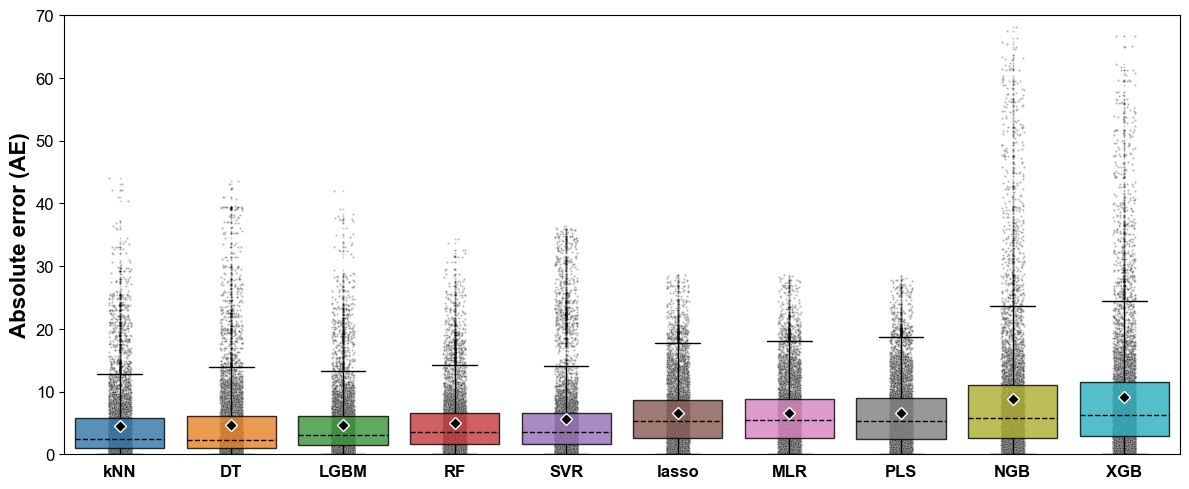

In [106]:
# figure set-up - viability
f, boxplot = plt.subplots(figsize=(12, 5))

# choose color scheme
#palette = sns.color_palette("colorblind")
#palette = sns.color_palette("pastel")
palette = sns.color_palette("tab10")
#palette = sns.color_palette("CMRmap")

# set boxplot style
boxplot = sns.set_style("white")

# r2_scores
r2_scores = {
    'RF': 0.519,
    'MLR': 0.291,
    'lasso': 0.297,
    'kNN': 0.49,
    'PLS': 0.290,
    'SVR': 0.265,
    'DT': 0.377,
    'LGBM': 0.513,
    'XGB': 0.565, 
    'NGB': 0.541 
}

# boxplot set up and box-whis style
boxplot = sns.boxplot(palette=palette, 
                      data=df6, saturation = 0.8,
                      boxprops = dict(linewidth=1.0, edgecolor='black', alpha = 0.8),
                      whiskerprops = dict(linewidth=1.0, color='black'),
                      capprops = dict(linewidth=1.0, color='black'),
                      flierprops=dict(marker="d", markerfacecolor= "black", markeredgecolor="black", 
                                      markersize =0.5, alpha=0.2),
                      medianprops=dict(color="black", linewidth=1.0, linestyle= '--'), 
                      showmeans=True,
                      meanprops=dict(marker="D", markerfacecolor="black", alpha=1.0,
                                     markeredgecolor="white", markersize=6.5, linewidth=0.05, zorder=10))

# include each datapoint
boxplot = sns.stripplot(data=df6, marker="o", edgecolor='white', 
                        alpha=0.3, size=1.5, linewidth=0.3, color='black', jitter = True, zorder=0)
'''
# include the mae and r2 value on each bar of plot
for i, col in enumerate(df6.columns):
    mae = df6[col].mean()
    r2 = r2_scores[col]
    median = df6[col].median()
    boxplot.text(i, median -0.2,
                 f'MAE: {mae:.2f}\nR²: {r2:.2f}',
                 ha='center', va='top',   # important: anchor from top
                 fontsize=10, color='black', weight='bold')
'''
# Title
#boxplot.axes.set_title("ML model performance ranked by mean absolute error", fontsize=18, color="white", weight="bold")
#boxplot.set_xlabel("Model performance - MAE transfection efficiency ", fontsize=12)
boxplot.set_ylabel("Absolute error (AE)", fontsize=16, color='black', 
                   weight="bold")

# y-axis limits and interval
boxplot.set(ylim=(0, df6.max().max()))

# x-axis rotation and text color
boxplot.set_xticklabels(boxplot.get_xticklabels(),rotation = 0, color='black', fontsize=12)

# x-axis and y-axis tick color
boxplot.tick_params(colors='black', which='both')  # 'both' refers to minor and major axes

# x-axis and y-axis label color
boxplot.axes.yaxis.label.set_color('black')
boxplot.axes.xaxis.label.set_color('black')

# format graph outline (color)
boxplot.spines['left'].set_color('black')
boxplot.spines['bottom'].set_color('black')
boxplot.spines['right'].set_color('black')
boxplot.spines['top'].set_color('black')

# add tick marks on x-axis or y-axis
boxplot.tick_params(bottom=False, left=True)

plt.yticks(fontsize=12)
plt.xticks(fontsize=12, weight = "bold")

plt.tight_layout()
plt.savefig('Fig_1a_model_performance_viability.png', dpi=900, format = 'png', transparent=True, bbox_inches='tight')
plt.show()


## MODEL SCREENING - MEAN ABSOLUTE ERROR (MFI FOLDS)

/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_12960/1309526035.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_xticklabels(boxplot.get_xticklabels(),rotation = 0, color='black', fontsize=12)


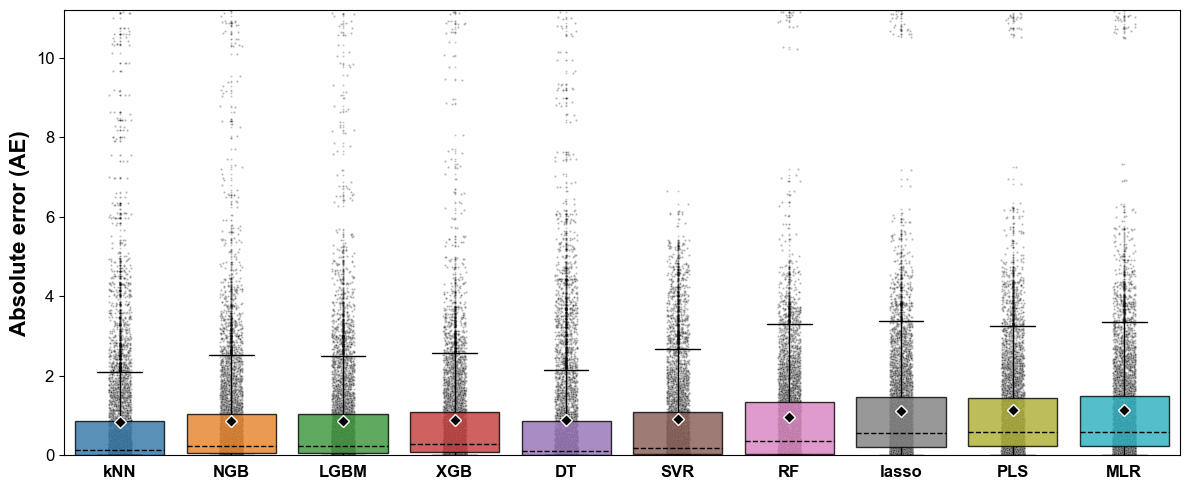

In [109]:
# figure set-up - mfi
f, boxplot = plt.subplots(figsize=(12, 5))

# choose color scheme
#palette = sns.color_palette("colorblind")
#palette = sns.color_palette("pastel")
palette = sns.color_palette("tab10")
#palette = sns.color_palette("CMRmap")

# set boxplot style
boxplot = sns.set_style("white")

# boxplot set up and box-whis style
boxplot = sns.boxplot(palette=palette, 
                      data=df7, saturation = 0.8,
                      boxprops = dict(linewidth=1.0, edgecolor='black', alpha = 0.8),
                      whiskerprops = dict(linewidth=1.0, color='black'),
                      capprops = dict(linewidth=1.0, color='black'),
                      flierprops=dict(marker="d", markerfacecolor= "black", markeredgecolor="black", 
                                      markersize =0.5, alpha=0.2),
                      medianprops=dict(color="black", linewidth=1.0, linestyle= '--'), 
                      showmeans=True,
                      meanprops=dict(marker="D", markerfacecolor="black", alpha=1.0,
                                     markeredgecolor="white", markersize=6.5, linewidth=0.05, zorder=10))

# include each datapoint
boxplot = sns.stripplot(data=df7, marker="o", edgecolor='white', 
                        alpha=0.3, size=1.5, linewidth=0.3, color='black', jitter = True, zorder=0)

# include the mae and r2 value on each bar of plot
'''for i, col in enumerate(df7.columns):
    mae = df7[col].mean()
    r2 = r2_scores[col]
    median = df7[col].median()
    boxplot.text(i, median -0.2,
                 f'MAE: {mae:.2f}\nR²: {r2:.2f}',
                 ha='center', va='top',   # important: anchor from top
                 fontsize=10, color='black', weight='bold')
'''
# Title
#boxplot.axes.set_title("ML model performance ranked by mean absolute error", fontsize=18, color="white", weight="bold")
#boxplot.set_xlabel("Model performance - MAE transfection efficiency ", fontsize=12)
boxplot.set_ylabel("Absolute error (AE)", fontsize=16, color='black', 
                   weight="bold")

# y-axis limits and interval
boxplot.set(ylim=(0, df7.max().max()*0.5))
#sns.despine(left=False, bottom=False)

# x-axis rotation and text color
boxplot.set_xticklabels(boxplot.get_xticklabels(),rotation = 0, color='black', fontsize=12)

# x-axis and y-axis tick color
boxplot.tick_params(colors='black', which='both')  # 'both' refers to minor and major axes

# x-axis and y-axis label color
boxplot.axes.yaxis.label.set_color('black')
boxplot.axes.xaxis.label.set_color('black')

# format graph outline (color)
boxplot.spines['left'].set_color('black')
boxplot.spines['bottom'].set_color('black')
boxplot.spines['right'].set_color('black')
boxplot.spines['top'].set_color('black')

# add tick marks on x-axis or y-axis
boxplot.tick_params(bottom=False, left=True)

plt.yticks(fontsize=12)
plt.xticks(fontsize=12, weight = "bold")

plt.tight_layout()
plt.savefig('Fig_1a_model_performance_mfi.png', dpi=900, format = 'png', transparent=True, bbox_inches='tight')
plt.show()


## MODEL SCREENING - MEAN ABSOLUTE ERROR (TRANSFECTION)

/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_12960/3376467199.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_xticklabels(boxplot.get_xticklabels(),rotation = 0, color='black', fontsize=12)


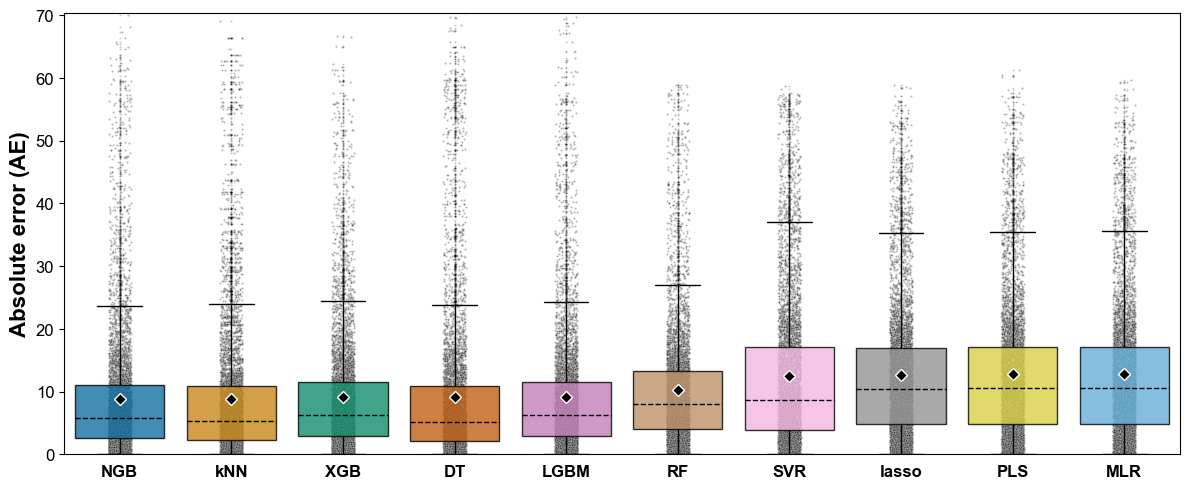

In [110]:
# figure set-up - transfection
f, boxplot = plt.subplots(figsize=(12, 5))

# choose color scheme
palette = sns.color_palette("colorblind")
#palette = sns.color_palette("pastel")
#palette = sns.color_palette("tab10")
#palette = sns.color_palette("CMRmap")

# set boxplot style
boxplot = sns.set_style("white")

# r2_scores
r2_scores = {
    'RF': 0.771,
    'MLR': 0.669,
    'lasso': 0.671,
    'kNN': 0.768,
    'PLS': 0.669,
    'SVR': 0.648,
    'DT': 0.729,
    'LGBM': 0.779,
    'XGB': 0.793, 
    'NGB': 0.785 
}

# boxplot set up and box-whis style
boxplot = sns.boxplot(palette=palette, 
                      data=df5, saturation = 0.8,
                      boxprops = dict(linewidth=1.0, edgecolor='black', alpha = 0.8),
                      whiskerprops = dict(linewidth=1.0, color='black'),
                      capprops = dict(linewidth=1.0, color='black'),
                      flierprops=dict(marker="d", markerfacecolor= "black", markeredgecolor="black", 
                                      markersize =0.5, alpha=0.2),
                      medianprops=dict(color="black", linewidth=1.0, linestyle= '--'), 
                      showmeans=True,
                      meanprops=dict(marker="D", markerfacecolor="black", alpha=1.0,
                                     markeredgecolor="white", markersize=6.5, linewidth=0.05, zorder=10))

# include each datapoint
boxplot = sns.stripplot(data=df5, marker="o", edgecolor='white', 
                        alpha=0.3, size=1.5, linewidth=0.3, color='black', jitter = True, zorder=0)

# include the mae and r2 value on each bar of plot
'''
for i, col in enumerate(df5.columns):
    mae = df5[col].mean()
    r2 = r2_scores[col]
    median = df5[col].median()
    boxplot.text(i, median - 0.5,
                 f'MAE: {mae:.2f}\nR²: {r2:.2f}',
                 ha='center', va='top',   # important: anchor from top
                 fontsize=7.5, color='black', weight='bold')
'''
# Title
#boxplot.axes.set_title("ML model performance ranked by mean absolute error", fontsize=18, color="white", weight="bold")
#boxplot.set_xlabel("Model performance - MAE transfection efficiency ", fontsize=12)
boxplot.set_ylabel("Absolute error (AE)", fontsize=16, color='black', 
                   weight="bold")

# y-axis limits and interval
boxplot.set(ylim=(0, df5.max().max()*0.9))
#sns.despine(left=False, bottom=False)

# x-axis rotation and text color
boxplot.set_xticklabels(boxplot.get_xticklabels(),rotation = 0, color='black', fontsize=12)

# x-axis and y-axis tick color
boxplot.tick_params(colors='black', which='both')  # 'both' refers to minor and major axes

# x-axis and y-axis label color
boxplot.axes.yaxis.label.set_color('black')
boxplot.axes.xaxis.label.set_color('black')

# format graph outline (color)
boxplot.spines['left'].set_color('black')
boxplot.spines['bottom'].set_color('black')
boxplot.spines['right'].set_color('black')
boxplot.spines['top'].set_color('black')

# add tick marks on x-axis or y-axis
boxplot.tick_params(bottom=False, left=True)

plt.yticks(fontsize=12)
plt.xticks(fontsize=12, weight = "bold")

plt.tight_layout()
plt.savefig('Fig_1a_model_performance_transfection.png', dpi=900, format = 'png', transparent=True, bbox_inches='tight')
plt.show()


In [71]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(df9['MLR'], df9['XGB'])
print(p)

5.761562836312288e-120


In [76]:
PE_transfection = pd.DataFrame(RF_trans['Percent_Error'], columns=['RF'])
PE_transfection['RF'] = RF_trans['Percent_Error']
PE_transfection['MLR'] = MLR_trans['Percent_Error']
PE_transfection['lasso'] = lasso_trans['Percent_Error']
PE_transfection['kNN'] = kNN_trans['Percent_Error']
PE_transfection['PLS'] = PLS_trans['Percent_Error']
PE_transfection['SVR'] = SVR_trans['Percent_Error']
PE_transfection['DT'] = DT_trans['Percent_Error']
PE_transfection['LGBM'] = LGBM_trans['Percent_Error']
PE_transfection['XGB'] = XGB_trans['Percent_Error']
PE_transfection['NGB'] = NGB_trans['Percent_Error']

sorted_index = PE_transfection.mean().sort_values().index
df_percent = PE_transfection[sorted_index]

/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_60875/1352112538.py:14: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  boxplot = sns.boxplot(palette=palette,
/var/folders/4z/bv_ylkxx6tg2gmdw82dqfdym0000gn/T/ipykernel_60875/1352112538.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_xticklabels(boxplot.get_xticklabels(),rotation = 0, color='black', fontsize=12)


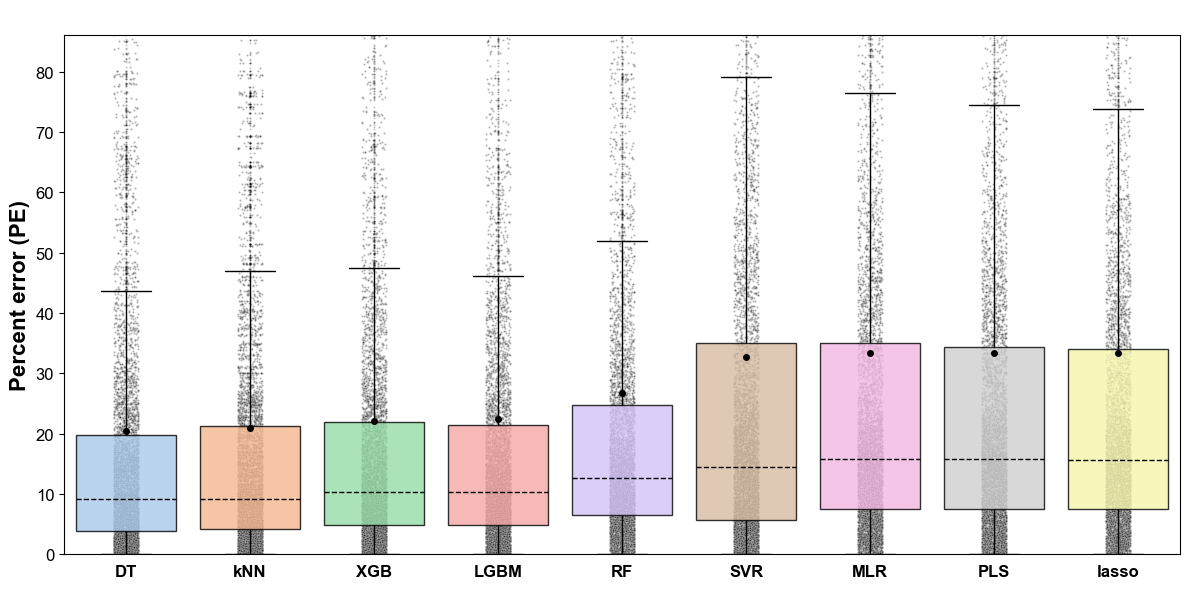

In [101]:
# figure set-up - size
f, boxplot = plt.subplots(figsize=(12, 6))

# choose color scheme
#palette = sns.color_palette("Paired")
palette = sns.color_palette("pastel")
#palette = sns.color_palette("tab10")
p#alette = sns.color_palette("CMRmap")

# set boxplot style
boxplot = sns.set_style("white")

# boxplot set up and box-whis style
boxplot = sns.boxplot(palette=palette, 
                      data=df_percent, saturation = 0.8,
                      boxprops = dict(linewidth=1.0, edgecolor='black', alpha = 0.8),
                      whiskerprops = dict(linewidth=1.0, color='black'),
                      capprops = dict(linewidth=1.0, color='black'),
                      flierprops=dict(marker="d", markerfacecolor= "black", markeredgecolor="black", 
                                      markersize =0.5, alpha=0.2),
                      medianprops=dict(color="black", linewidth=1.0, linestyle= '--'), 
                      showmeans=True,
                      meanprops=dict(marker="o", markerfacecolor="black", alpha=1.0,
                                     markeredgecolor="black", markersize=4, linewidth=0.05, zorder=10))

# include each datapoint
boxplot = sns.stripplot(data=df_percent, marker="o", edgecolor='white', 
                        alpha=0.3, size=1.5, linewidth=0.3, color='black', jitter = True, zorder=0)

# Title
boxplot.axes.set_title("ML model performance ranked by percent error", fontsize=18, color="white", weight="bold")

# Title - x-axis/y-axis
#boxplot.set_xlabel("Model index", fontsize=12)
boxplot.set_ylabel("Percent error (PE)", fontsize=16, color='black', 
                   weight="bold")

# y-axis limits and interval
boxplot.set(ylim=(0, df9.max().max()*1.1))
#sns.despine(left=False, bottom=False)

# x-axis rotation and text color
boxplot.set_xticklabels(boxplot.get_xticklabels(),rotation = 0, color='black', fontsize=12)

# x-axis and y-axis tick color
boxplot.tick_params(colors='black', which='both')  # 'both' refers to minor and major axes

# x-axis and y-axis label color
boxplot.axes.yaxis.label.set_color('black')
boxplot.axes.xaxis.label.set_color('black')

# format graph outline (color)
boxplot.spines['left'].set_color('black')
boxplot.spines['bottom'].set_color('black')
boxplot.spines['right'].set_color('black')
boxplot.spines['top'].set_color('black')

# add tick marks on x-axis or y-axis
boxplot.tick_params(bottom=False, left=True)


plt.yticks(fontsize=12)
plt.xticks(fontsize=12, weight = "bold")

plt.tight_layout()

#plt.savefig('Figure_model_performance_transfection_percent_error', dpi=900, format = 'png', transparent=True, bbox_inches='tight')

plt.show()

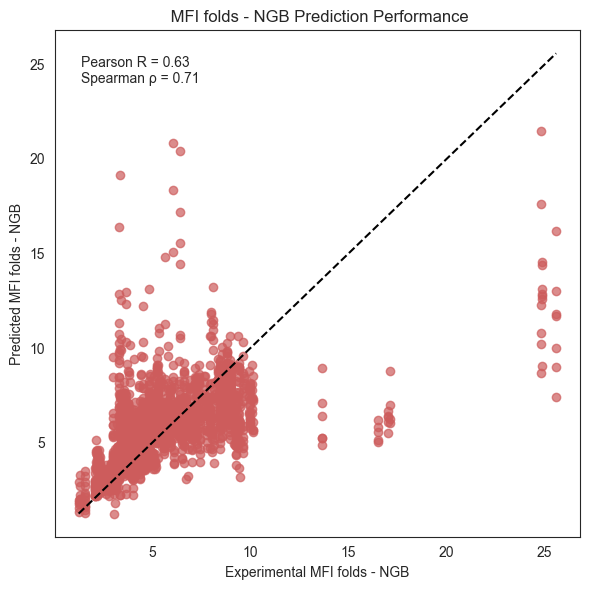

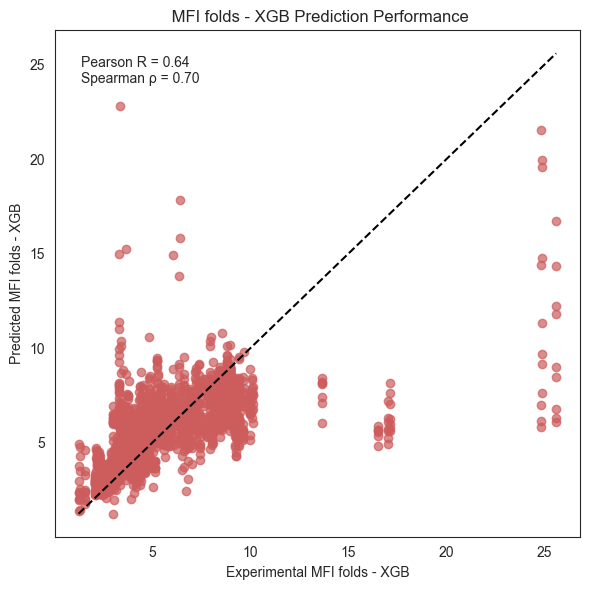

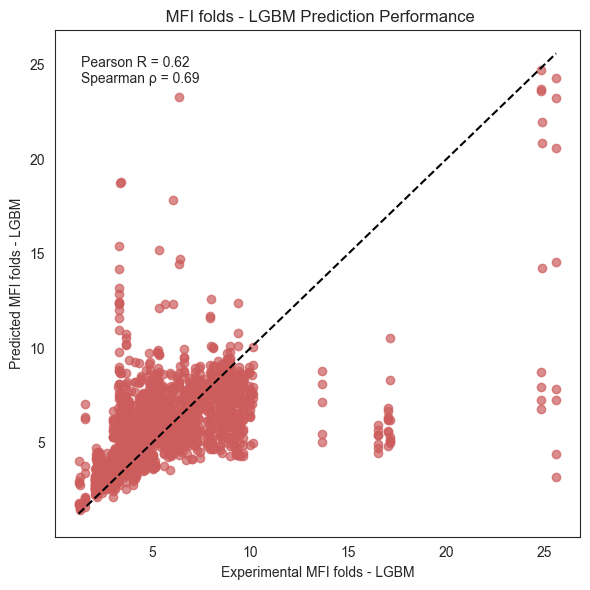

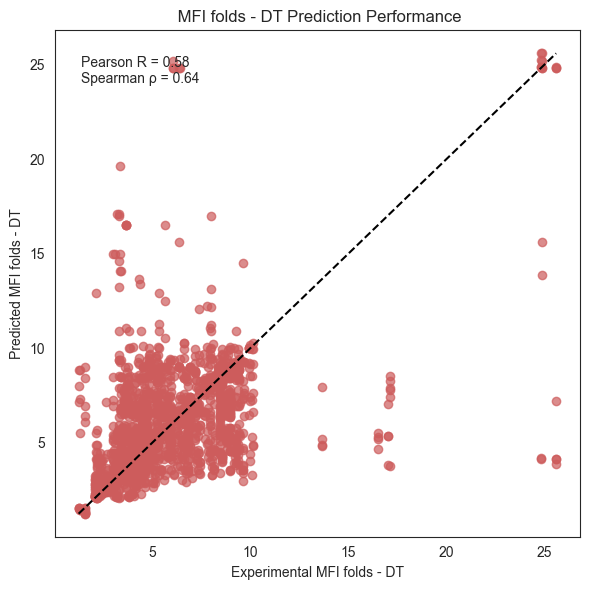

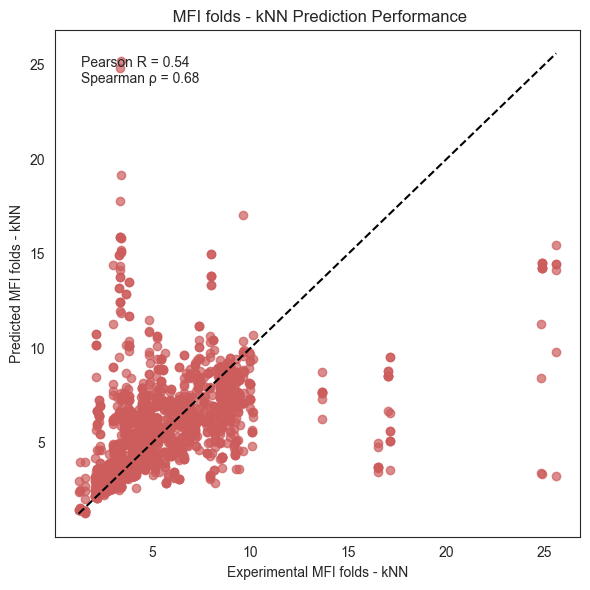

In [83]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

datasets = {
    "MFI folds - NGB": NGB_mfi,
    "MFI folds - XGB": XGB_mfi,
    "MFI folds - LGBM": LGBM_mfi, 
    "MFI folds - DT": DT_mfi,
    "MFI folds - kNN": kNN_mfi
}

for name, data in datasets.items():

    sampled_data = data.sample(n=4000, random_state=42)
    
    y_true = sampled_data['Experimental_Value']
    y_pred = sampled_data['Predicted_Value']
    
    # correlations computation
    pearson_r, pearson_p = pearsonr(y_true, y_pred)
    spearman_r, spearman_p = spearmanr(y_true, y_pred)
    
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.7, color='indianred')
    #color='mediumseagreen'
    #color='teal'
    #color='salmon'

    plt.plot([min(y_true), max(y_true)],
             [min(y_true), max(y_true)],
             '--', color='black')
    
    # labels (dynamic)
    plt.xlabel(f"Experimental {name}")
    plt.ylabel(f"Predicted {name}")
    plt.title(f" {name} Prediction Performance")
    
    # correlation text
    plt.text(
        0.05, 0.95,
        f"Pearson R = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
        transform=plt.gca().transAxes,
        verticalalignment='top'
    )
    
    plt.tight_layout()
    plt.savefig(f"{name}_performance.png", dpi=600)
    plt.show()
    plt.close()